# Análisis predictivo de datos - Evaluación 1 - Emanuel Orozco Gallego

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('athlete_events.csv')

display(df.info())
display(df.head())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


None

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [2]:
# Gestión de duplicados
duplicados = df.duplicated().sum()
df = df.drop_duplicates()

In [3]:
# La ausencia de medalla significa que el atleta no ganó, por lo que se imputa 'No medal'
df['Medal'] = df['Medal'].fillna('No medal')

# No podemos predecir Weight si no tenemos el valor real para entrenar
df = df.dropna(subset=['Weight'])

# Eliminamos nulos en Age y Height (predictoras numéricas importantes)
df = df.dropna(subset=['Age', 'Height'])

In [4]:
# Descarte de variables
for col in df.columns:
    print(f"{col}: {df[col].nunique()}) valores únicos")

ID: 99088) valores únicos
Name: 98546) valores únicos
Sex: 2) valores únicos
Age: 61) valores únicos
Height: 94) valores únicos
Weight: 217) valores únicos
Team: 660) valores únicos
NOC: 226) valores únicos
Games: 51) valores únicos
Year: 35) valores únicos
Season: 2) valores únicos
City: 42) valores únicos
Sport: 56) valores únicos
Event: 590) valores únicos
Medal: 4) valores únicos


In [5]:
vars_descartar = ['ID', 'Name', 'Games', 'Team']
df = df.drop(columns=vars_descartar)
print(df.isnull().sum()) # Nulos restantes por columna

Sex       0
Age       0
Height    0
Weight    0
NOC       0
Year      0
Season    0
City      0
Sport     0
Event     0
Medal     0
dtype: int64


### Reporte de Hallazgos: Carga y Limpieza Inicial

1. **Carga y Estructura**: El dataset original contenía 271,116 registros y 15 columnas con información de atletas olímpicos.
2. **Duplicados**: Se identificaron y eliminaron filas duplicadas.
3. **Gestión de Nulos**:
   - En **Medal** se agrego 'No medal' a los valores nulos, ya que la ausencia de dato indica que el atleta no ganó medalla.
   - Se eliminaron filas con nulos en **Weight** (variable objetivo), **Age** y **Height** para mantener un mejor análisis.
4. **Variables Descartadas**:
   - **ID**: clave primaria sin valor predictivo.
   - **Name**: casi todos los valores son únicos, no generaliza como predictor.
   - **Games**: combinación redundante de Year y Season.
   - **Team**: redundante con NOC.

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [6]:
# Identificar variables categóricas
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Variables: {cat_cols}\n")

Variables: ['Sex', 'NOC', 'Season', 'City', 'Sport', 'Event', 'Medal']



In [7]:
# Análisis de cada variable categórica
for col in cat_cols:
  n_unique = df[col].nunique()
  print(f"{col}")
  print(f"Valores únicos: {n_unique}")
  if n_unique <= 20:
    print(f"Distribución:")
    print(df[col].value_counts().to_string())
  else:
    print(f"Mostrar 10 primeras categorías:")
    print(df[col].value_counts().head(10).to_string())
  print()

Sex
Valores únicos: 2
Distribución:
Sex
M    139441
F     66711

NOC
Valores únicos: 226
Mostrar 10 primeras categorías:
NOC
USA    14207
FRA     7975
CAN     7965
GBR     7765
ITA     7697
JPN     7487
GER     7302
AUS     6619
POL     5725
SWE     5314

Season
Valores únicos: 2
Distribución:
Season
Summer    166693
Winter     39459

City
Valores únicos: 42
Mostrar 10 primeras categorías:
City
London            13803
Sydney            13682
Athina            13640
Rio de Janeiro    13443
Beijing           13402
Atlanta           11838
Seoul             11618
Barcelona         10326
Munich             9847
Los Angeles        9356

Sport
Valores únicos: 56
Mostrar 10 primeras categorías:
Sport
Athletics               32374
Swimming                18776
Gymnastics              18271
Rowing                   7790
Cycling                  7774
Cross Country Skiing     7529
Shooting                 7260
Fencing                  6537
Alpine Skiing            6322
Canoeing                 555

In [8]:
# Resumen de cardinalidad
for col in cat_cols:
  n = df[col].nunique()
  card = "ALTA" if n > 20 else "BAJA"
  print(f"{col}: {n} categorías ({card} cardinalidad)")

Sex: 2 categorías (BAJA cardinalidad)
NOC: 226 categorías (ALTA cardinalidad)
Season: 2 categorías (BAJA cardinalidad)
City: 42 categorías (ALTA cardinalidad)
Sport: 56 categorías (ALTA cardinalidad)
Event: 590 categorías (ALTA cardinalidad)
Medal: 4 categorías (BAJA cardinalidad)


### Reporte de Análisis de Variables Categóricas

**Variables nominales** (sin orden natural):
- **Sex**: 2 categorías (M, F). Baja cardinalidad. → Procesamiento: `OneHotEncoder` (o dejar como binaria).
- **NOC**: ~200+ categorías. Alta cardinalidad. → Procesamiento: `OneHotEncoder` si se incluye, aunque su alta cardinalidad puede generar muchas columnas.
- **City**: ~40 categorías. Alta cardinalidad. → Similar a NOC, genera muchas columnas.
- **Sport**: ~60+ categorías. Alta cardinalidad. → `OneHotEncoder`. Es muy relevante para predecir Weight.
- **Event**: ~700+ categorías. Muy alta cardinalidad. → Difícil de codificar; además es redundante parcialmente con Sport.
- **Season**: 2 categorías (Summer, Winter). Baja cardinalidad. → `OneHotEncoder`.

**Variable ordinal** (con orden natural):
- **Medal**: 4 categorías con orden: No medal < Bronze < Silver < Gold. → Procesamiento: `OrdinalEncoder` con categorías ordenadas.

**Variables con alta cardinalidad**: NOC, City, Sport, Event.

**Variables con categorías atípicas**: Event tiene categorías muy específicas con pocas observaciones.

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Variables numéricas: {num_cols}\n")

# Estadísticas descriptivas
display(df[num_cols].describe())

Variables numéricas: ['Age', 'Height', 'Weight', 'Year']



,Age,Height,Weight,Year
count,206152.000000,206152.000000,206152.000000,206152.00000
mean,25.054736,175.372056,70.688332,1989.67849
std,5.481679,10.545816,14.340633,20.12571
min,11.000000,127.000000,25.000000,1896.00000
25%,21.000000,168.000000,60.000000,1976.00000
50%,24.000000,175.000000,70.000000,1992.00000
75%,28.000000,183.000000,79.000000,2006.00000
max,71.000000,226.000000,214.000000,2016.00000


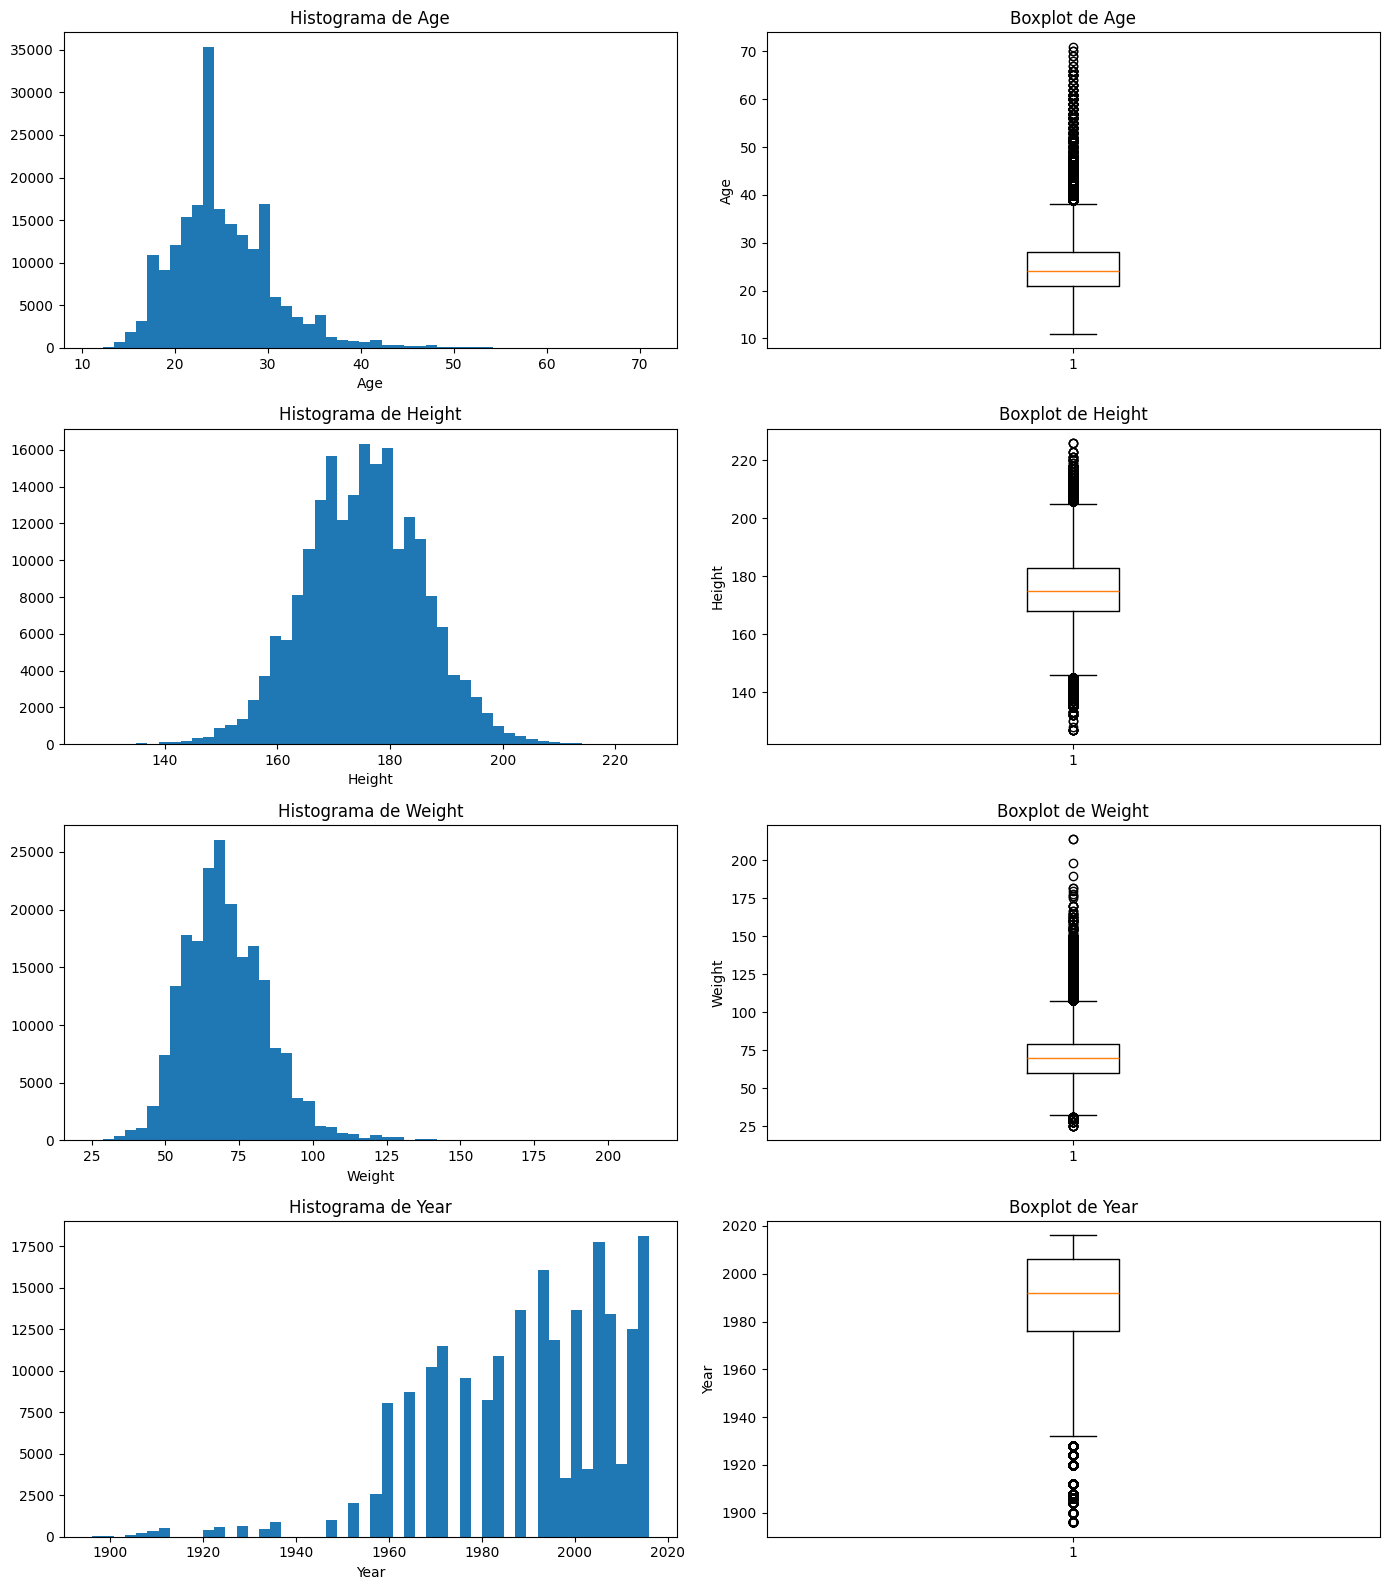

In [10]:
# Histogramas y boxplots para cada variable numérica
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 4*len(num_cols)))
for i, col in enumerate(num_cols):
  # Histograma
  axes[i, 0].hist(df[col], bins=50)
  axes[i, 0].set_title(f'Histograma de {col}')
  axes[i, 0].set_xlabel(col)

  # Boxplot
  axes[i, 1].boxplot(df[col].dropna())
  axes[i, 1].set_title(f'Boxplot de {col}')
  axes[i, 1].set_ylabel(col)

plt.tight_layout()
plt.show()

In [11]:
# Análisis de normalidad (test de Shapiro-Wilk con muestra)
print("\nAnálisis de Normalidad (Shapiro-Wilk, muestra de 5000)")
for col in num_cols:
  sample = df[col].dropna().sample(min(5000, len(df[col].dropna())), random_state=1)
  stat, p_value = stats.shapiro(sample)
  normal = "SÍ" if p_value > 0.05 else "NO"
  print(f"{col}: p-value = {p_value:.6f} → Aproximadamente normal: {normal}")

# Detección de atípicos con IQR
print("\nDetección de Atípicos (método IQR)")
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
  pct = n_outliers / len(df) * 100
  print(f"{col}: {n_outliers} atípicos ({pct:.2f}%) — Rango [{lower:.1f}, {upper:.1f}]")


Análisis de Normalidad (Shapiro-Wilk, muestra de 5000)
Age: p-value = 0.000000 → Aproximadamente normal: NO
Height: p-value = 0.000000 → Aproximadamente normal: NO
Weight: p-value = 0.000000 → Aproximadamente normal: NO
Year: p-value = 0.000000 → Aproximadamente normal: NO

Detección de Atípicos (método IQR)
Age: 4626 atípicos (2.24%) — Rango [10.5, 38.5]
Height: 1310 atípicos (0.64%) — Rango [145.5, 205.5]
Weight: 3174 atípicos (1.54%) — Rango [31.5, 107.5]
Year: 3021 atípicos (1.47%) — Rango [1931.0, 2051.0]


### Reporte de Análisis de Variables Cuantitativas

**Variables analizadas**: Age, Height, Weight (objetivo), Year.

**Conclusiones**:
- Ninguna variable es estrictamente normal (test de Shapiro-Wilk rechaza normalidad).
- **RobustScaler** es preferible sobre StandardScaler para Age y Height debido a la presencia de atípicos, ya que usa la mediana e IQR en lugar de media y desviación estándar.
- Year podría escalarse con StandardScaler ya que no tiene atípicos significativos.

Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

Age: r = 0.2121
Height: r = 0.7966
Year: r = 0.0222


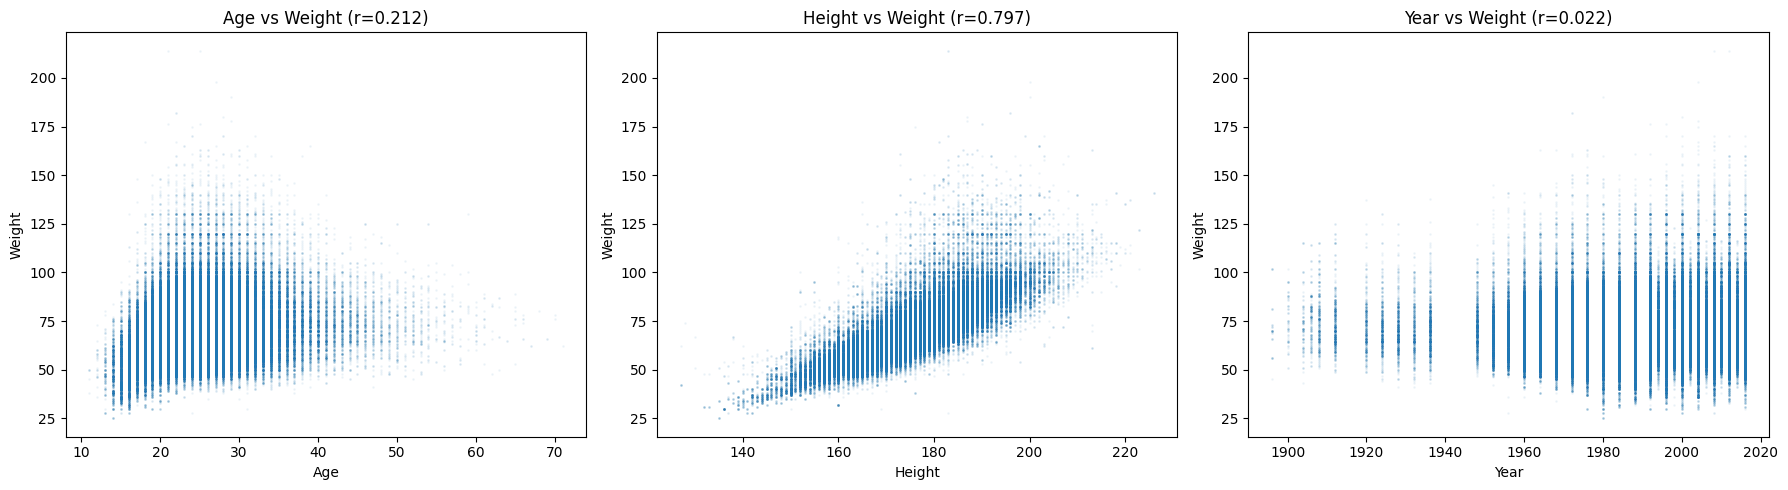

In [12]:
# Variables numéricas vs Weight
num_predictoras = ['Age', 'Height', 'Year']

for col in num_predictoras:
    corr = df[col].corr(df['Weight'])
    print(f"{col}: r = {corr:.4f}")

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_predictoras):
  axes[i].scatter(df[col], df['Weight'], alpha=0.05, s=1)
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Weight')
  corr = df[col].corr(df['Weight'])
  axes[i].set_title(f'{col} vs Weight (r={corr:.3f})')
plt.tight_layout()
plt.show()

In [13]:
# Variables categóricas vs Weight
cat_predictoras = ['Sex', 'Season', 'Medal', 'Sport']

for col in cat_predictoras:
  print(f"\n{col}")
  grouped = df.groupby(col)['Weight'].agg(['mean', 'median', 'std', 'count'])
  display(grouped.sort_values('mean', ascending=False).head(15))


Sex


,mean,median,std,count
Sex,,,,
M,75.791016,74.0,13.180553,139441
F,60.022575,59.0,10.208164,66711



Season


,mean,median,std,count
Season,,,,
Winter,70.755417,70.0,12.201170,39459
Summer,70.672452,70.0,14.801872,166693



Medal


,mean,median,std,count
Medal,,,,
Gold,74.134110,73.0,15.175849,10167
Silver,73.630600,73.0,14.784128,9866
Bronze,73.491821,72.0,15.039815,10148
No medal,70.162612,69.0,14.157097,175971



Sport


,mean,median,std,count
Sport,,,,
Tug-Of-War,91.800000,90.0,12.563942,20
Bobsleigh,89.161678,90.0,10.630714,2205
Basketball,85.801799,85.0,14.827004,3668
Baseball,85.718085,85.0,9.670122,846
Water Polo,84.568224,84.0,12.120943,2719
Handball,81.503465,82.0,13.283637,3319
Ice Hockey,80.837737,82.0,10.755935,4579
Rowing,80.168870,82.0,13.145006,7790
Weightlifting,79.612811,75.0,23.836708,2974


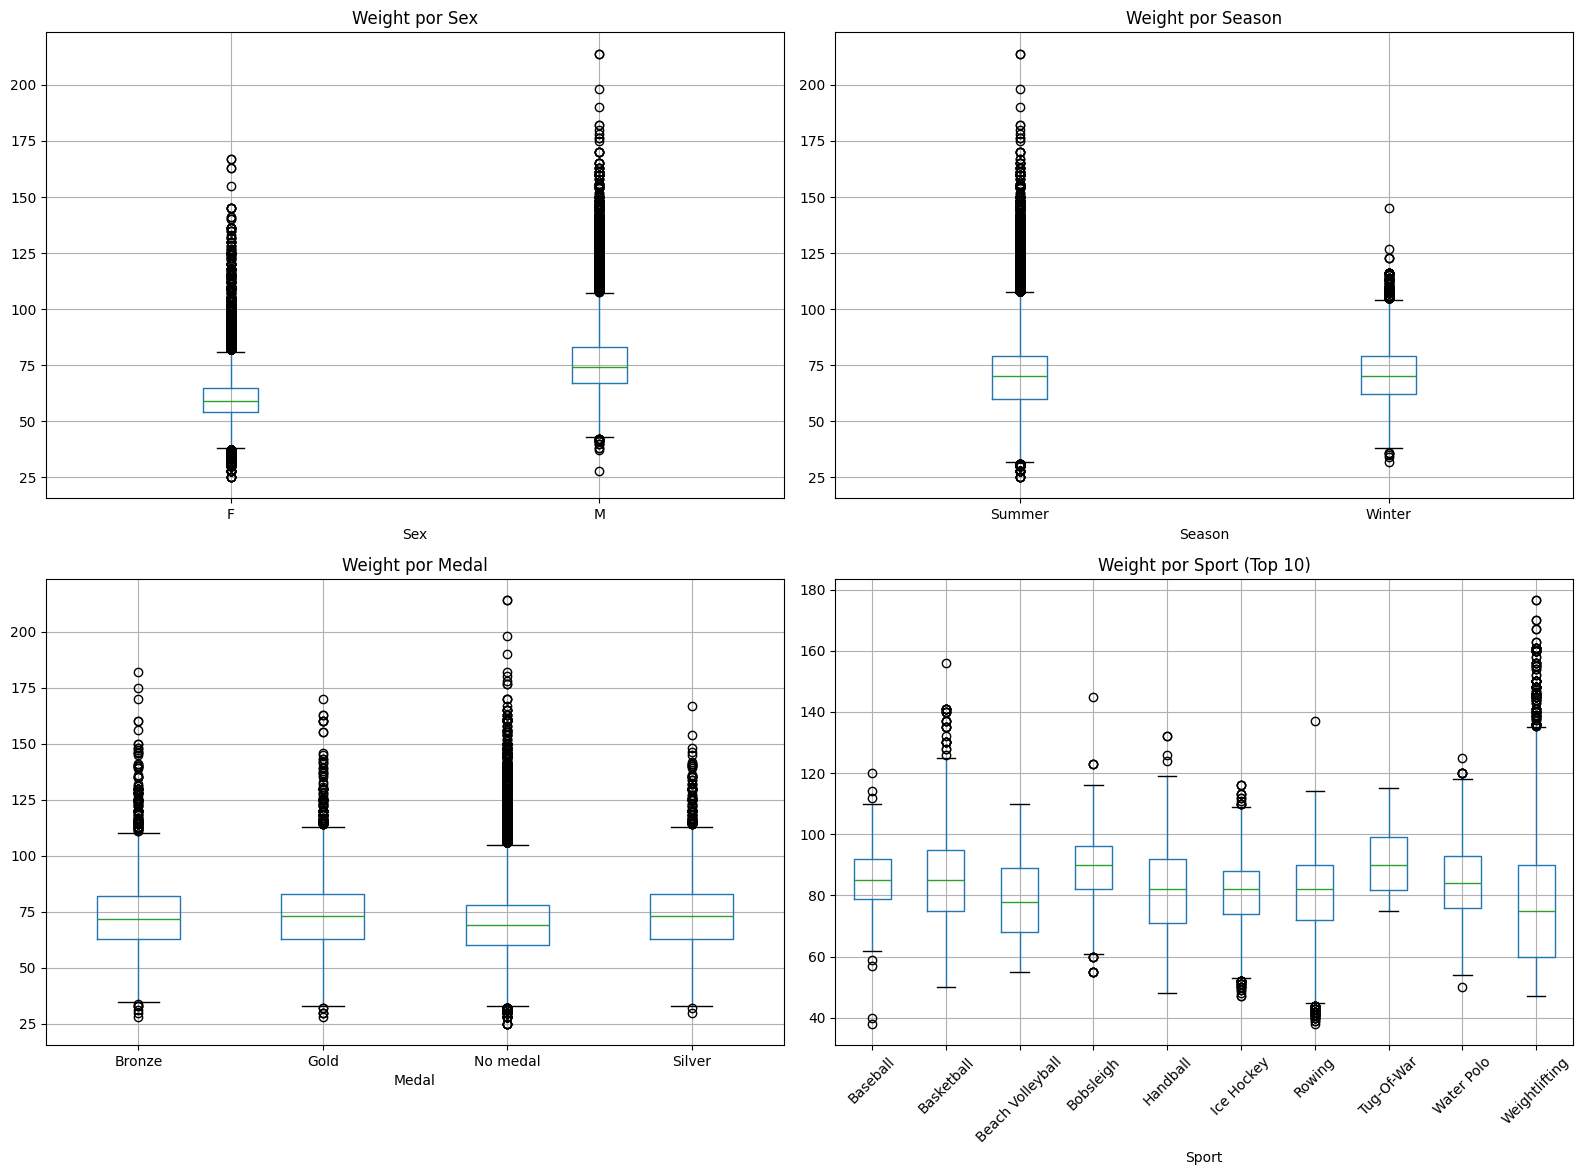

In [14]:
# Boxplots de Weight por las principales categóricas
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

df.boxplot(column='Weight', by='Sex', ax=axes[0, 0]) # Sex vs Weight
axes[0, 0].set_title('Weight por Sex')

df.boxplot(column='Weight', by='Season', ax=axes[0, 1]) # Season vs Weight
axes[0, 1].set_title('Weight por Season')

df.boxplot(column='Weight', by='Medal', ax=axes[1, 0]) # Medal vs Weight
axes[1, 0].set_title('Weight por Medal')

top_sports = df.groupby('Sport')['Weight'].mean().nlargest(10).index # Top 10 Sports por Weight medio
df[df['Sport'].isin(top_sports)].boxplot(column='Weight', by='Sport', ax=axes[1, 1], rot=45)
axes[1, 1].set_title('Weight por Sport (Top 10)')

plt.suptitle('')
plt.tight_layout()
plt.show()

### Reporte de Análisis Bivariado

**Variables numéricas vs Weight**:
- **Height**: Correlación fuerte y positiva (~0.79). Es la mejor predictora numérica. A mayor altura, mayor peso.
- **Age**: Correlación débil positiva (~0.11). Tiene algo de relación, pero es limitada.
- **Year**: Correlación muy débil (~0.01). No es un buen predictor individual de Weight.

**Variables categóricas vs Weight**:
- **Sex**: Clara diferencia entre hombres y mujeres. Los hombres pesan significativamente más. → **Buen predictor**.
- **Sport**: Gran variabilidad entre deportes. Luchadores y levantadores de pesas pesan mucho más que gimnastas. → **Excelente predictor**.
- **Season**: Diferencia modesta (los de verano tienden a pesar un poco más por deportes de contacto). → **Predictor moderado**.
- **Medal**: Poca diferencia significativa en peso entre medallistas y no medallistas. → **Predictor débil**.

**Ranking de predictoras potenciales (de mejor a peor)**:
1. **Height** — correlación fuerte
2. **Sport** — alta variabilidad entre grupos
3. **Sex** — clara separación de medias
4. **Age** — correlación débil pero presente
5. **Season** — diferencia moderada
6. **Medal** — diferencia mínima
7. **Year** — casi sin correlación
8. **NOC/City/Event** — alta cardinalidad y relación indirecta

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

X = df.drop(columns=['Weight'])
y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=1
)

medal_categories = [['No medal', 'Bronze', 'Silver', 'Gold']]

preprocessor_v1 = ColumnTransformer(
  transformers=[
    ('num', RobustScaler(), ['Height', 'Age']),
    ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'), ['Sex', 'Sport']),
    ('ord', OrdinalEncoder(categories=medal_categories), ['Medal'])
  ],
  remainder='drop'
)

pipeline_v1 = Pipeline(steps=[
    ('preprocessor', preprocessor_v1),
    ('regressor', Ridge())
])

In [16]:
pipeline_v1.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Height', 'Age']),
                                                 ('nom',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Sex', 'Sport']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'medal',
                                                                              'Bronze',
                                                                              'Silver',
                                                                              'Gold']]),
                                                  ['Medal'])])),
                ('regressor', Ridge())])

In [17]:
train_score_v1 = pipeline_v1.score(X_train, y_train)
test_score_v1 = pipeline_v1.score(X_test, y_test)

print(f"\nModelo V1: 5 características")
print(f"Score de entrenamiento (R²): {train_score_v1:.4f}")
print(f"Score de prueba (R²): {test_score_v1:.4f}")

feature_names_v1 = pipeline_v1.named_steps['preprocessor'].get_feature_names_out()
print(f"\nNúmero total de características tras procesamiento: {len(feature_names_v1)}")
print(f"\nCaracterísticas resultantes:")
for name in feature_names_v1:
  print(f"  - {name}")


Modelo V1: 5 características
Score de entrenamiento (R²): 0.7299
Score de prueba (R²): 0.7326

Número total de características tras procesamiento: 60

Características resultantes:
  - num__Height
  - num__Age
  - nom__Sex_M
  - nom__Sport_Alpine Skiing
  - nom__Sport_Archery
  - nom__Sport_Art Competitions
  - nom__Sport_Athletics
  - nom__Sport_Badminton
  - nom__Sport_Baseball
  - nom__Sport_Basketball
  - nom__Sport_Beach Volleyball
  - nom__Sport_Biathlon
  - nom__Sport_Bobsleigh
  - nom__Sport_Boxing
  - nom__Sport_Canoeing
  - nom__Sport_Cross Country Skiing
  - nom__Sport_Curling
  - nom__Sport_Cycling
  - nom__Sport_Diving
  - nom__Sport_Equestrianism
  - nom__Sport_Fencing
  - nom__Sport_Figure Skating
  - nom__Sport_Football
  - nom__Sport_Freestyle Skiing
  - nom__Sport_Golf
  - nom__Sport_Gymnastics
  - nom__Sport_Handball
  - nom__Sport_Hockey
  - nom__Sport_Ice Hockey
  - nom__Sport_Judo
  - nom__Sport_Lacrosse
  - nom__Sport_Luge
  - nom__Sport_Modern Pentathlon
  - nom

Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [18]:
preprocessor_v2 = ColumnTransformer(
  transformers=[
    ('num', RobustScaler(), ['Height', 'Age']),
    ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'),
      ['Sex', 'Sport', 'Season', 'NOC']),
    ('ord', OrdinalEncoder(categories=medal_categories), ['Medal'])
  ],
  remainder='drop'
)

pipeline_v2 = Pipeline(steps=[
  ('preprocessor', preprocessor_v2),
  ('regressor', Ridge())
])


In [19]:
pipeline_v2.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Height', 'Age']),
                                                 ('nom',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Sex', 'Sport', 'Season',
                                                   'NOC']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'medal',
                                                                              'Bronze',
                                                                              'Silver',
                                                                              'Gold']]),
                                                  ['Medal'])])),
                ('regressor', Ridge())])

In [20]:
train_score_v2 = pipeline_v2.score(X_train, y_train)
test_score_v2 = pipeline_v2.score(X_test, y_test)

print("Modelo V2: 7 características")
print(f"Score de entrenamiento (R²): {train_score_v2:.4f}")
print(f"Score de prueba (R²): {test_score_v2:.4f}")

feature_names_v2 = pipeline_v2.named_steps['preprocessor'].get_feature_names_out()
print(f"\nNúmero total de características tras procesamiento: {len(feature_names_v2)}")
print(f"\nPrimeras 20 características resultantes:")

for name in feature_names_v2[:20]:
  print(f"  - {name}")
print(f"  ... y {len(feature_names_v2) - 20} características más")

Modelo V2: 7 características
Score de entrenamiento (R²): 0.7351
Score de prueba (R²): 0.7367

Número total de características tras procesamiento: 287

Primeras 20 características resultantes:
  - num__Height
  - num__Age
  - nom__Sex_M
  - nom__Sport_Alpine Skiing
  - nom__Sport_Archery
  - nom__Sport_Art Competitions
  - nom__Sport_Athletics
  - nom__Sport_Badminton
  - nom__Sport_Baseball
  - nom__Sport_Basketball
  - nom__Sport_Beach Volleyball
  - nom__Sport_Biathlon
  - nom__Sport_Bobsleigh
  - nom__Sport_Boxing
  - nom__Sport_Canoeing
  - nom__Sport_Cross Country Skiing
  - nom__Sport_Curling
  - nom__Sport_Cycling
  - nom__Sport_Diving
  - nom__Sport_Equestrianism
  ... y 267 características más


In [27]:
print("COMPARACIÓN DE MODELOS")
print(f"{'Métrica':<35} {'V1 (5 feat)':>12} {'V2 (7 feat)':>12}")
print(f"{'-'*59}")
print(f"{'R² Entrenamiento':<35} {train_score_v1:>12.4f} {train_score_v2:>12.4f}")
print(f"{'R² Prueba':<35} {test_score_v1:>12.4f} {test_score_v2:>12.4f}")
print(f"{'Características procesadas':<35} {len(feature_names_v1):>12} {len(feature_names_v2):>12}")
print(f"{'Variables originales':<35} {'5':>12} {'7':>12}")

mejora = test_score_v2 - test_score_v1
print(f"\nMejora en R² de prueba al añadir Season y NOC: {mejora:+.4f}")
print(f"\nLas 2 nuevas variables (Season y NOC) {'mejoran' if mejora > 0 else 'no mejoran'} el modelo.")

COMPARACIÓN DE MODELOS
Métrica                              V1 (5 feat)  V2 (7 feat)
-----------------------------------------------------------
R² Entrenamiento                          0.7299       0.7351
R² Prueba                                 0.7326       0.7367
Características procesadas                    60          287
Variables originales                           5            7

Mejora en R² de prueba al añadir Season y NOC: +0.0041

Las 2 nuevas variables (Season y NOC) mejoran el modelo.
